In [ ]:
from astropy.io import fits
import numpy as np
import emcee
import corner
import math
from astropy.coordinates import Angle
import astropy.units as units
import scipy.special as sp
import warnings
import itertools
from uncertainties import ufloat
from uv_fit import *
import sigfig

In [ ]:
# Source parameters for code -- do not change these
P_PARAMS = ['peak', 'ra', 'dec']
C_PARAMS = ['peak', 'ra', 'dec', 'sigma']
G_PARAMS = ['peak', 'ra', 'dec', 'sigma', 'ratio', 'vis_theta']
D_PARAMS = ['peak', 'ra', 'dec', 'r']

SOURCE_TYPES = {'p': [3, p_p0, p_prior, p_model, P_PARAMS], \
                'c': [4, c_p0, c_prior, c_model, C_PARAMS], \
                'g': [6, g_p0, g_prior, g_model, G_PARAMS], \
                'd': [4, d_p0, d_prior, d_model, D_PARAMS]}

In [ ]:
# uv_fit function edited to take in an a dictionary of info and an array of data instead of a fits file
def sim_uv_fit(info, vis, sources: list, priors: list = None, clean_output=True, corner_plot=True, additional_runs: int = 2):
    # priors = [[(i0_min, i0_max), (l0_min, l0_max), (m0_min, m0_max), (width_param_min, width_param_max), (ratio_min, ratio_max), (theta_min, theta_max)], ...]
    # but (tuple) for exclusive and [list] for inclusive
    # TODO: documentation
    '''
    Fit UV data from a FITS file with specified source types using MCMC.

    Parameters
    ----------
    info (dict): Dictionary containing UV data information.
    vis (array): Array of visibility data.
    sources (list): List of source types to fit. Each source type should be one of
                    'p' (point), 'c' (circular gaussian), 'g' (gaussian), 'd' (disk), or 'any' (try all and pick best fit).
    '''
    # Check additional_runs
    if additional_runs < 0:
        raise ValueError("additional_runs must be a non-negative integer.")

    # Check priors format
    if priors is not None:
        if len(priors) != len(sources):
            raise ValueError("Length of priors must match length of sources.")
        for i in range(len(priors)):
            if priors[i] is not None:
                if type(priors[i]) is not list:
                    raise ValueError("Each element in priors must be None or a list corresponding to a source.")
                if len(priors[i]) != 6:
                    raise ValueError("Each prior list must have 6 elements corresponding to ranges for peak, RA, declination, width parameter, ratio, and angle.")
                for i in range(len(priors[i])):
                    if priors[i][i] is not None:
                        if type(priors[i][i]) not in [list, tuple]:
                            raise ValueError("Each prior range must be None, a list (inclusive), or a tuple (exclusive).")
                        if len(priors[i][i]) != 2:
                            raise ValueError("Each prior range list or tuple must have exactly two elements: min and max.")

    # Check input source types
    if len(sources) == 0:
        raise ValueError("No sources specified. Try specifying one or more sources of type \
                         'p' (point), 'c' (circular gaussian), 'g' (gaussian), 'd' (disk), or 'any' (try all and pick best fit).")
    for source in sources:
        if source not in SOURCE_TYPES and source != 'any':
            raise ValueError(f"Source type '{source}' is not recognized. Source type must be one of the following: \
                            'p' (point), 'c' (circular gaussian), 'g' (gaussian), 'd' (disk), or 'any' (try all and pick best fit).")

    vis_priors = []
    if priors is None:
        priors = [None] * len(sources)
    for i in range(len(priors)):
        mini_vis_priors = []
        if priors[i] is not None:
            for j in range(len(priors[i])):
                if priors[i][j] is not None:
                    if j == 0:  # peak, keep as is
                        mini_vis_priors.append(priors[i][j])
                    elif j in [1, 2, 3]:  # ra, dec, width parameter
                        # convert from arcsec to radian
                        rad_min = float(Angle(priors[i][j][0], units.arcsec).to(units.radian).value)
                        rad_max = float(Angle(priors[i][j][1], units.arcsec).to(units.radian).value)
                        if type(priors[i][j]) is tuple:
                            mini_vis_priors.append((rad_min, rad_max))
                        else:
                            mini_vis_priors.append([rad_min, rad_max])
                    elif j == 4:  # ratio
                        mini_vis_priors.append(priors[i][j])
                    elif j == 5:  # angle
                        mini_vis_priors.append(priors[i][j] * np.pi/180) # convert from degrees to radians
                else:
                    mini_vis_priors.append(None)
            vis_priors.append(mini_vis_priors)
        else: # nothing to convert
            vis_priors.append([[None, None]] * 6)

    # Extract data from fits file
    cdelt1 = info['CDELT1']
    cunit1 = info['CUNIT1']
    naxis1 = info['NAXIS1']

    bmaj = info['BMAJ'] # cunit1
    bmin = info['BMIN'] # cunit1
    rad_bmaj = Angle(bmaj, cunit1).to(units.radian).value
    rad_bmin = Angle(bmin, cunit1).to(units.radian).value
    rad_barea = np.pi * rad_bmaj * rad_bmin / (4 * np.log(2))
    rad_pix = float(Angle(cdelt1, cunit1).to(units.radian).value)
    int_peaks = info['int_peak_val']
    int_coords = info['int_peak_coord']
    ext_peaks = info['ext_peak_val']
    ext_coords = info['ext_peak_coord']

    int_info = list(zip(int_peaks, int_coords))
    if type(ext_peaks) is list:
        ext_info = list(zip(ext_peaks, ext_coords))
    else:
        ext_info = []
    all_peaks = int_info + ext_info # list of tuples (peak_value, (l_coord, m_coord))
    all_peaks.sort(reverse=True) # sort by peak value
    n_peaks = len(all_peaks)
    if n_peaks < len(sources):
        warnings.warn(f"Number of detected peaks ({n_peaks}) is less than number of sources to fit ({len(sources)}).")

    freq_bin, u, v, re, im, w = [], [], [], [], [], []
    for row in vis:
        freq_bin_data, u_data, v_data, re_data, im_data, w_data = row
        freq_bin.append(int(freq_bin_data))
        u.append(int(u_data))
        v.append(int(v_data))
        re.append(float(re_data/w_data))
        im.append(float(im_data/w_data))
        w.append(float(w_data))

    # Adding in conjugate half of data
    freq_bin *= 2
    neg_u = [-1 * val for val in u]
    u += neg_u
    neg_v = [-1 * val for val in v]
    v += neg_v
    re *= 2
    neg_im = [-1 * val for val in im]
    im += neg_im
    w *= 2

    freq_bin = np.array(freq_bin)
    u = np.array(u)
    v = np.array(v)
    re = np.array(re)
    im = np.array(im)
    w = np.array(w)

    # Estimate total flux from small baselines
    small_baselines = []
    q = np.sqrt(u**2 + v**2)
    baseline_indices = np.argsort(q, axis=None)
    small_baselines_indices = baseline_indices[:len(baseline_indices)//20]  # smallest 5% of baselines
    for i in small_baselines_indices:
        small_baselines.append(np.sqrt(im[i]**2 + re[i]**2))
    total_flux_median = np.median(small_baselines)
    total_flux_mean = np.mean(small_baselines)
    total_flux_sd = np.std(small_baselines)
    if abs(total_flux_median - total_flux_mean) > total_flux_sd:
        total_flux = total_flux_median
    else:
        total_flux = total_flux_mean

    # All possible permutations
    n_sources = len(sources)
    sample_space = list(SOURCE_TYPES.keys()) * n_sources
    all_permutations = list(itertools.permutations(sample_space, n_sources))

    for i in range(n_sources):
        if sources[i] != 'any':
            all_permutations = [p for p in all_permutations if p[i] == sources[i]] # remove unwanted permutations
    all_permutations = list(set(all_permutations)) # remove duplicates

    all_results = []
    for permutation in all_permutations:
        # Calculate n_params and n_walkers
        n_params = 0
        for i in range(n_sources):
            source = permutation[i]
            n_params += SOURCE_TYPES[source][0]
        n_walkers = 2 * n_params

        # Initial guesses
        for i in range(n_sources):
            source = permutation[i]
            peak = all_peaks[i][0] if i < n_peaks else all_peaks[-1][0]
            coord0 = all_peaks[i][1] if i < n_peaks else all_peaks[-1][1]
            rad_coord = (float(Angle(coord0[0], units.arcsec).to(units.radian).value), float(Angle(coord0[1], units.arcsec).to(units.radian).value))
            if i == 0:
                p0 = SOURCE_TYPES[source][1](peak, rad_coord, rad_pix, rad_barea, total_flux, n_walkers)
            else:
                mini_p0 = SOURCE_TYPES[source][1](peak, rad_coord, rad_pix, rad_barea, total_flux, n_walkers)
                if i >= n_peaks: # edit ra, dec initial guesses
                    for j in range(n_walkers):
                        mini_p0[j,1] = np.random.uniform(-naxis1/2*rad_pix, naxis1/2*rad_pix)
                        mini_p0[j,2] = np.random.uniform(-naxis1/2*rad_pix, naxis1/2*rad_pix)
                p0 = np.append(p0, mini_p0, axis=1)

        # Set up and run MCMC
        n_steps = 100
        sampler = emcee.EnsembleSampler(n_walkers, n_params, log_probability, args=(permutation, vis_priors, re, im, u, v, w, rad_bmaj, rad_bmin))
        try:
            state = sampler.run_mcmc(p0, n_steps)
        except emcee.autocorr.AutocorrError:
            pass
        except ValueError:
            print(f"Error encountered during MCMC run for permutation {permutation}. Skipping this permutation.")
            all_results.append({'permutation': permutation, 'n_params': n_params, 'result': None, 'chi2': np.inf, 'chain': None})
            continue
        tau = sampler.get_autocorr_time(quiet=True)
        if np.isnan(tau).all():
            warnings.warn(f"Autocorrelation time for first run of {permutation} could not be estimated; all values are NaN.", RuntimeWarning)
            all_results.append({'permutation': permutation, 'n_params': n_params, 'result': None, 'chi2': np.inf, 'chain': None})
            continue
        int_tau = math.ceil(np.nanmax(tau))
        steps_to_50_tau = abs(int_tau * 50 - n_steps)
        try:
            sampler.run_mcmc(state, steps_to_50_tau)
        except ValueError:
            print(f"Error encountered during second MCMC run for permutation {permutation}. Skipping this permutation.")
            all_results.append({'permutation': permutation, 'n_params': n_params, 'result': None, 'chi2': np.inf, 'chain': None})
            continue
        chain = sampler.get_chain(discard = int_tau * 10, flat=True)
        log_probs = sampler.get_log_prob(discard = int_tau * 10, flat=True)
        max_prob_index = np.argmax(log_probs)

        # Find parameter estimates and uncertainties and calculate chi2
        result = {}
        model = 0.0
        start = 0
        for i in range(n_sources):
            source = permutation[i]
            n_source_params = SOURCE_TYPES[source][0]
            source_chain = chain[:, start:start+n_source_params]
            source_result = {'type': source}
            temp_medians = [] # to store medians
            temp_bests = {} # to store best values (that maximimize probability)
            temp_max_probs = [] # to store max prob values
            for j in range(n_source_params):
                samples = source_chain[:, j]
                temp_max_probs.append(samples[max_prob_index])
                samples_med = np.median(samples)
                samples_sd = np.nanstd(samples)
                param_name = SOURCE_TYPES[source][4][j]
                source_result[param_name] = (float(samples_med), float(samples_sd))
                temp_bests[param_name] = float(samples[max_prob_index])
                temp_medians.append(samples_med)
            source_result['best'] = temp_bests
            model += SOURCE_TYPES[source][3](temp_max_probs, u, v, rad_bmaj, rad_barea)
            result[f'source_{i+1}'] = source_result
            start += n_source_params
        chi2 = float(np.sum(w * ((re - model.real)**2 + (im - model.imag)**2)))

        all_results.append({'permutation': permutation, 'n_params': n_params, 'result': result, 'chi2': chi2, 'chain': chain})

    # Rank permutations by chi2
    all_results.sort(key=lambda x: x['chi2']) # lowest to highest chi2
    best_perm = all_results[0]['permutation']
    best_result = all_results[0]['result']

    # Do it again with refined initial guesses, if requested
    for reps in range(additional_runs):  # two additional refinement iterations
        second_results = []
        for permutation_info in all_results:
            # Calculate n_params and n_walkers
            permutation = permutation_info['permutation']
            chain = permutation_info['chain']
            n_params = 0
            for i in range(n_sources):
                source = permutation[i]
                n_params += SOURCE_TYPES[source][0]
            n_walkers = 2 * n_params

            # New initial guesses from previous results
            for i in range(n_sources):
                source = permutation[i]
                coord0 = all_peaks[i][1] if i < n_peaks else all_peaks[-1][1]
                rad_coord = (float(Angle(coord0[0], units.arcsec).to(units.radian).value), float(Angle(coord0[1], units.arcsec).to(units.radian).value))
                if permutation_info['result'] is None: # fitting didn't happen, so can't actually refine
                    peak = all_peaks[i][0] if i < n_peaks else all_peaks[-1][0]
                    if i == 0:
                        p1 = SOURCE_TYPES[source][1](peak, rad_coord, rad_pix, rad_barea, total_flux, n_walkers)
                    else:
                        mini_p1 = SOURCE_TYPES[source][1](peak, rad_coord, rad_pix, rad_barea, total_flux, n_walkers)
                        if i >= n_peaks: # edit ra, dec initial guesses
                            for j in range(n_walkers):
                                mini_p1[j,1] = np.random.uniform(-naxis1/2*rad_pix, naxis1/2*rad_pix)
                                mini_p1[j,2] = np.random.uniform(-naxis1/2*rad_pix, naxis1/2*rad_pix)
                        p1 = np.append(p1, mini_p1, axis=1)
                else:
                    rad_position = best_result[f'source_{i+1}']['best']['ra'], best_result[f'source_{i+1}']['best']['dec']
                    source_result = permutation_info['result'][f'source_{i+1}']
                    best_params = []
                    med_sd = []
                    point_intensity = None
                    for param_name in SOURCE_TYPES[source][4]:
                        med_sd.append(source_result[param_name])
                        best_params.append(source_result[param_name][0])

                    # use p fitting to help c/g/d fitting if p chi2 was better than c/g/d chi2 in first run
                    resolved = True
                    if source != 'p':
                        if best_params[3] < rad_bmaj/2:  # conditions for unresolved source
                            resolved = False
                    if not resolved:
                        temp_perm = best_perm[:i] + ('p',) + best_perm[i+1:]
                        if temp_perm == best_perm:
                            temp = best_result[f'source_{i+1}']['best']['peak']
                        else:
                            temp = sim_uv_fit(info, vis, list(temp_perm), priors=priors, clean_output=True, corner_plot=False, additional_runs=0)[0]['result'][f'source_{i+1}']['peak'][0]
                            point_intensity = temp if type(temp) is float else temp[0]

                    # use c fitting to help g fitting if c chi2 was better than g chi2 in first run
                    c_peak = None
                    c_sigma = None
                    if source == 'g' and best_perm[i] == 'c':
                        c_peak = best_result[f'source_{i+1}']['best']['peak']
                        c_sigma = best_result[f'source_{i+1}']['best']['sigma']
                    if i == 0:
                        try:
                            p1 = all_p1(med_sd, resolved, point_intensity, c_peak, c_sigma, rad_position, rad_bmaj, rad_pix, n_walkers, chain)
                        except:
                            print(med_sd)
                            return
                    else:
                        try:
                            p1 = np.append(p1, all_p1(med_sd, resolved, point_intensity, c_peak, c_sigma, rad_position, rad_bmaj, rad_pix, n_walkers, chain), axis=1)
                        except:
                            print(med_sd)
                            return

                    # edit vis_priors if unresolved source
                    if not resolved:
                        if vis_priors[i] is None:
                            vis_priors[i] = [(None, None)] * 6
                        vis_priors[i][1] = (-rad_pix+rad_coord[0], rad_pix+rad_coord[0]) # ra within one pixel of image domain result
                        vis_priors[i][2] = (-rad_pix+rad_coord[1], rad_pix+rad_coord[1]) # dec within one pixel of image domain result

            # Set up and run MCMC
            n_steps = 100
            sampler1 = emcee.EnsembleSampler(n_walkers, n_params, log_probability, args=(permutation, vis_priors, re, im, u, v, w, rad_bmaj, rad_bmin))
            try:
                state = sampler1.run_mcmc(p1, n_steps)
            except emcee.autocorr.AutocorrError:
                pass
            except ValueError:
                print(f"Error encountered during second MCMC run for permutation {permutation}. Skipping this permutation.")
                second_results.append({'permutation': permutation, 'n_params': n_params, 'result': None, 'chi2': np.inf, 'chain': None})
                continue
            tau = sampler1.get_autocorr_time(quiet=True)
            if np.isnan(tau).all():
                warnings.warn(f"Autocorrelation time for second run of {permutation} could not be estimated; all values are NaN.", RuntimeWarning)
                second_results.append({'permutation': permutation, 'n_params': n_params, 'result': None, 'chi2': np.inf, 'chain': None})
                continue
            int_tau = math.ceil(np.nanmax(tau))
            steps_to_50_tau = abs(int_tau * 50 - n_steps)
            try:
                sampler1.run_mcmc(state, steps_to_50_tau)
            except ValueError:
                print(f"Error encountered during second MCMC run for permutation {permutation}. Skipping this permutation.")
                second_results.append({'permutation': permutation, 'n_params': n_params, 'result': None, 'chi2': np.inf, 'chain': None})
                continue
            chain1 = sampler1.get_chain(discard = int_tau * 10, flat=True)
            log_probs1 = sampler1.get_log_prob(discard = int_tau * 10, flat=True)
            max_prob_index1 = np.argmax(log_probs1)

            # Find parameter estimates and uncertainties and calculate chi2
            result = {}
            model = 0.0
            start = 0
            for i in range(n_sources):
                source = permutation[i]
                n_source_params = SOURCE_TYPES[source][0]
                source_chain = chain1[:, start:start+n_source_params]
                source_result = {'type': source}
                temp_medians = [] # to store medians for chi2 calculation
                temp_bests = {} # to store best values (that maximimize probability)
                temp_max_probs = [] # to store max prob values
                for j in range(n_source_params):
                    samples = source_chain[:, j]
                    temp_max_probs.append(samples[max_prob_index1])
                    samples_med = np.median(samples)
                    samples_sd = np.nanstd(samples)
                    param_name = SOURCE_TYPES[source][4][j]
                    source_result[param_name] = (float(samples_med), float(samples_sd))
                    temp_bests[param_name] = float(samples[max_prob_index1])
                    temp_medians.append(samples_med)
                source_result['best'] = temp_bests
                model += SOURCE_TYPES[source][3](temp_max_probs, u, v, rad_bmaj, rad_barea)
                result[f'source_{i+1}'] = source_result
                start += n_source_params
            chi2 = float(np.sum(w * ((re - model.real)**2 + (im - model.imag)**2)))
            second_results.append({'permutation': permutation, 'n_params': n_params, 'result': result, 'chi2': chi2, 'chain': chain1})
        all_results = []
        for permutation_info in second_results:
            all_results.append(permutation_info)
        # Rank permutations by chi2
        all_results.sort(key=lambda x: x['chi2']) # lowest to highest chi2
        best_perm = all_results[0]['permutation']
        best_result = all_results[0]['result']

    # Bayesian Information Criterion
    n = len(re)
    for permutation_info in all_results:
        k = permutation_info['n_params']
        chi2 = permutation_info['chi2']
        if chi2 is np.inf:
            permutation_info['bic'] = np.inf
            continue
        bic = k * np.log(n) + chi2
        permutation_info['bic'] = float(bic)
    all_results.sort(key=lambda x: x['bic']) # lowest to highest BIC

    if clean_output:
        for permutation_info in all_results:
            result = permutation_info['result']
            start = 0
            permutation_chain = permutation_info['chain']
            if result is None:
                continue
            for i in range(n_sources):
                source_key = f'source_{i+1}'
                source_result = result[source_key]
                source_type = source_result['type']
                source_params = SOURCE_TYPES[source_type][4]
                n_source_params = SOURCE_TYPES[source_type][0]
                n_walkers = 2 * n_source_params
                source_chain = permutation_chain[:, start:start+n_source_params]

                # peak
                peak_chain = source_chain[:, 0]
                peak_sigmas = tuple([float(sigfig.round(sigma, sigfigs=3)) for sigma in sigmas(peak_chain)])
                source_result['peak'] = (round_tuple((source_result['peak'][0], source_result['peak'][1])), peak_sigmas)

                # convert ra, dec to arcsec
                ra_chain = source_chain[:, 1]
                dec_chain = source_chain[:, 2]
                ra_sigmas = tuple([float(sigfig.round(Angle(sigma, units.radian).to(units.arcsec).value, sigfigs=3)) for sigma in sigmas(ra_chain)])
                dec_sigmas = tuple([float(sigfig.round(Angle(sigma, units.radian).to(units.arcsec).value, sigfigs=3)) for sigma in sigmas(dec_chain)])
                source_result['ra'] = (round_tuple(tuple([float(Angle(l, units.radian).to(units.arcsec).value) for l in source_result['ra']])), ra_sigmas)
                source_result['dec'] = (round_tuple(tuple([float(Angle(m, units.radian).to(units.arcsec).value) for m in source_result['dec']])), dec_sigmas)

                if source_type != 'p': # convert visibility width to image width in arcsec
                    width_chain = source_chain[:, 3]
                    width_sigmas = tuple([float(sigfig.round(Angle(sigma, units.radian).to(units.arcsec).value, sigfigs=3)) for sigma in sigmas(width_chain)])
                    source_result[source_params[3]] = (round_tuple((float(Angle(source_result[source_params[3]][0], units.radian).to(units.arcsec).value), \
                                                    float(Angle(source_result[source_params[3]][1], units.radian).to(units.arcsec).value))), width_sigmas)

                if source_type == 'g': # convert visibility theta to image theta in degrees and convert sigma and ratio into major and minor
                    theta_chain = source_chain[:, 5]
                    vis_theta_sigmas = sigmas(theta_chain)
                    theta_sigmas = tuple([float(round((theta * 180/np.pi - 90) % 90, 3)) for theta in vis_theta_sigmas])
                    uvis_theta = ufloat(source_result['vis_theta'][0], source_result['vis_theta'][1])
                    uimg_theta = (uvis_theta * (180/np.pi) - 90)
                    del source_result['vis_theta']
                    source_result['theta'] = (round_tuple((uimg_theta.n % 90, uimg_theta.s)), theta_sigmas)

                    usigma_min = ufloat(source_result['sigma'][0][0], source_result['sigma'][0][1])
                    uratio = ufloat(source_result['ratio'][0], source_result['ratio'][1])
                    usigma_maj = usigma_min / uratio
                    del source_result['sigma']
                    del source_result['ratio']
                    source_result['sigma_maj'] = (round_tuple((usigma_maj.n, usigma_maj.s)), tuple([float(sigfig.round(width / uratio.n, sigfigs=3)) for width in width_sigmas]))
                    source_result['sigma_min'] = (round_tuple((usigma_min.n, usigma_min.s)), tuple([float(sigfig.round(width, sigfigs=3)) for width in width_sigmas]))

                del source_result['best']

                start += n_source_params

    if corner_plot:
        for j in range(len(all_results)):
            permutation_info = all_results[j]
            result = permutation_info['result']
            if result is None:
                continue
            chain = permutation_info['chain']
            start = 0
            end = 0
            for i in range(n_sources):
                source_key = f'source_{i+1}'
                source_result = result[source_key]
                source_type = source_result['type']
                n_params = SOURCE_TYPES[source_type][0]
                source_params = SOURCE_TYPES[source_type][4]
                end += n_params
                if i == n_sources-1:
                    fig = corner.corner(chain[:, start:], labels=source_params)
                else:
                    fig = corner.corner(chain[:, start:end], labels=source_params)
                fig.suptitle(f'Permutation {j+1}: {permutation_info["permutation"]}, source {i+1} of {n_sources}')
                start = end

    for permutation_info in all_results:
        del permutation_info['chain']

    return all_results


In [ ]:
def generate_synthetic_info_vis(fits_file, sources, peaks, coords, noise, widths=None, ratios=None, thetas=None):
    # peak in Jy, coords in arcsec, noise in Jy, widths in arcsec, ratios unitless, thetas in degrees
    num_sources = len(sources)
    if num_sources == 0:
        raise ValueError("At least one peak, coordinate, and source type must be provided.")
    if num_sources != len(peaks):
        raise ValueError("Length of sources and peaks must be the same.")
    if num_sources != len(coords):
        raise ValueError("Length of sources and coords must be the same.")
    for i in range(num_sources):
        if sources[i] not in SOURCE_TYPES.keys():
            raise ValueError(f"Source type '{sources[i]}' is not recognized. Source type must be one of the following: \
                            'p' (point), 'c' (circular gaussian), 'g' (gaussian), or 'd' (disk).")
        if type(coords[i]) not in [tuple, list] or len(coords[i]) != 2:
            raise ValueError(f"Coordinate for source {i+1} must be a tuple or list of length 2 representing (ra, dec) in radians.")
    if widths is not None and num_sources != len(widths):
        raise ValueError("Length of sources and widths must be the same if specifying widths.")
    if ratios is not None and num_sources != len(ratios):
        raise ValueError("Length of sources and ratios must be the same if specifying ratios.")
    if thetas is not None and num_sources != len(thetas):
        raise ValueError("Length of sources and thetas must be the same if specifying thetas.")

    num_widths = 0
    num_ratios = 0
    num_thetas = 0
    for source in sources:
        if source in ['c', 'd', 'g']:
            num_widths += 1
            if source == 'g':
                num_ratios += 1
                num_thetas += 1

    if widths is not None:
        if len(widths) != num_widths:
            raise ValueError(f"{num_widths} sources require widths, but only {len(widths)} have been given.")
    if ratios is not None:
        if len(ratios) != num_ratios:
            raise ValueError(f"{num_ratios} sources require ratios, but only {len(ratios)} have been given.")
    if thetas is not None:
        if len(thetas) != num_thetas:
            raise ValueError(f"{num_thetas} sources require thetas, but only {len(thetas)} have been given.")

    file = fits.open(fits_file)
    data = file[1].data
    cdelt1 = file[0].header['CDELT1']
    cunit1 = file[0].header['CUNIT1']
    naxis1 = file[0].header['NAXIS1']
    naxis2 = file[0].header['NAXIS2']
    bmaj = file[0].header['BMAJ']
    bmin = file[0].header['BMIN']

    arcsec_bmaj = Angle(bmaj, cunit1).to(units.arcsec).value
    search_radius = arcsec_bmaj + 2

    pix_field_center = ((naxis1-1)/2, (naxis2-1)/2)

    int_peaks = []
    int_coords = []
    ext_peaks = []
    ext_coords = []

    for i in range(num_sources):
        if np.sqrt((coords[i][0] - pix_field_center[0])**2 + (coords[i][1] - pix_field_center[1])**2) <= search_radius:
            int_peaks.append(peaks[i])
            int_coords.append(coords[i])
        else:
            ext_peaks.append(peaks[i])
            ext_coords.append(coords[i])

    info = {}
    info['CDELT1'] = cdelt1
    info['CUNIT1'] = cunit1
    info['NAXIS1'] = naxis1
    info['BMAJ'] = bmaj
    info['BMIN'] = bmin
    info['int_peak_val'] = int_peaks
    info['int_peak_coord'] = int_coords
    info['ext_peak_val'] = ext_peaks
    info['ext_peak_coord'] = ext_coords

    vis_err = noise * np.sqrt(len(data)) * np.sqrt(2)
    weight = 1/(vis_err**2)

    vis = []
    clean_re = []
    clean_im = []

    width_counter = 0
    g_counter = 0
    for i in range(num_sources):
        l0 = Angle(coords[i][0], units.arcsec).to(units.radian).value
        m0 = Angle(coords[i][1], units.arcsec).to(units.radian).value
        model_func = SOURCE_TYPES[sources[i]][3]
        source_info = [peaks[i], l0, m0]
        if source[i] in ['c', 'd', 'g']:
            source_info.append(Angle(widths[width_counter], units.arcsec).to(units.radian).value)
            width_counter += 1
            if source[i] == 'g':
                source_info.append(ratios[g_counter])
                source_info.append(thetas[g_counter] * np.pi/180) # convert from degrees to radians
                g_counter += 1
        for j in range(len(data)):
            row = data[j]
            model = model_func(source_info, row['U'], row['V'], bmaj, np.pi * bmaj * bmin / (4 * np.log(2)))
            if i == 0:
                clean_re.append(model.real)
                clean_im.append(model.imag)
            else:
                print(clean_re)
                clean_re[j] += model.real
                clean_im[j] += model.imag

    for i in range(len(data)):
        row = data[i]
        new_row = (row['Frequency'], row['U'], row['V'], (np.random.normal(scale=vis_err) + clean_re[i]) * weight, (np.random.normal(scale=vis_err) + clean_im[i]) * weight, weight)
        vis.append(new_row)

    return info, vis

In [ ]:
# High SNR point source at field center
info, vis = generate_synthetic_info_vis('../data/uv_test/3c84.uvfits', ['p'], [1], [(0, 0)], 0.0001)
sim_uv_fit(info, vis, sources=['any'], additional_runs=4)

In [ ]:
# Low SNR point source at field center
info, vis = generate_synthetic_info_vis('../data/uv_test/3c84.uvfits', ['p'], [0.0008], [(0, 0)], 0.0002)
sim_uv_fit(info, vis, sources=['any'], additional_runs=4)

In [ ]:
# High SNR point source offset from field center
info, vis = generate_synthetic_info_vis('../data/uv_test/3c84.uvfits', ['p'], [1.6], [(2, -5)], 0.0002)
sim_uv_fit(info, vis, sources=['any'], additional_runs=4)

In [ ]:
# Low SNR point source offset from field center
info, vis = generate_synthetic_info_vis('../data/uv_test/3c84.uvfits', ['p'], [0.0003], [(-3, 2)], 0.0001)
sim_uv_fit(info, vis, sources=['any'], additional_runs=4)

In [ ]:
# High SNR small disk at field center
info, vis = generate_synthetic_info_vis('../data/uv_test/3c84.uvfits', ['d'], [2], [(0, 0)], 0.0004, [0.7])
sim_uv_fit(info, vis, sources=['any'], additional_runs=4)

In [ ]:
# Low SNR small disk at field center
info, vis = generate_synthetic_info_vis('../data/uv_test/3c84.uvfits', ['d'], [0.0012], [(0, 0)], 0.0004, [0.6])
sim_uv_fit(info, vis, sources=['any'], additional_runs=4)

In [ ]:
# High SNR small disk offset from field center
info, vis = generate_synthetic_info_vis('../data/uv_test/3c84.uvfits', ['d'], [1.7], [(-2.3, -2.2)], 0.0003, [0.6])
sim_uv_fit(info, vis, sources=['any'], additional_runs=4)

In [ ]:
# Low SNR small disk offset from field center
info, vis = generate_synthetic_info_vis('../data/uv_test/3c84.uvfits', ['d'], [0.0008], [(1, 3.4)], 0.0003, [0.7])
sim_uv_fit(info, vis, sources=['any'], additional_runs=4)

In [ ]:
# High SNR large disk at field center
info, vis = generate_synthetic_info_vis('../data/uv_test/3c84.uvfits', ['d'], [1.4], [(0, 0)], 0.0004, [3])
sim_uv_fit(info, vis, sources=['any'], additional_runs=4)

In [ ]:
# Low SNR large disk at field center
info, vis = generate_synthetic_info_vis('../data/uv_test/3c84.uvfits', ['d'], [0.0009], [(0, 0)], 0.0003, [3.1])
sim_uv_fit(info, vis, sources=['any'], additional_runs=4)

In [ ]:
# High SNR large disk offset from field center
info, vis = generate_synthetic_info_vis('../data/uv_test/3c84.uvfits', ['d'], [1.5], [(4.2, -3.8)], 0.0003, [2.7])
sim_uv_fit(info, vis, sources=['any'], additional_runs=4)


In [ ]:
# Low SNR large disk offset from field center
info, vis = generate_synthetic_info_vis('../data/uv_test/3c84.uvfits', ['d'], [0.0007], [(0, 4)], 0.0002, [2.8])
sim_uv_fit(info, vis, sources=['any'], additional_runs=4)

In [ ]:
# High SNR small circular Gaussian at field center
info, vis = generate_synthetic_info_vis('../data/uv_test/3c84.uvfits', ['c'], [1.8], [(0, 0)], 0.0004, [0.5])
sim_uv_fit(info, vis, sources=['any'], additional_runs=4)

In [ ]:
# Low SNR small circular Gaussian at field center
info, vis = generate_synthetic_info_vis('../data/uv_test/3c84.uvfits', ['c'], [0.0004], [(0, 0)], 0.0001, [0.4])
sim_uv_fit(info, vis, sources=['any'], additional_runs=4)

In [ ]:
# High SNR small circular Gaussian offset from field center
info, vis = generate_synthetic_info_vis('../data/uv_test/3c84.uvfits', ['c'], [1.6], [(3.5, -2.5)], 0.0004, [0.6])
sim_uv_fit(info, vis, sources=['any'], additional_runs=4)

In [ ]:
# Low SNR small circular Gaussian offset from field center
info, vis = generate_synthetic_info_vis('../data/uv_test/3c84.uvfits', ['c'], [0.0005], [(-4, 1)], 0.0001, [0.5])
sim_uv_fit(info, vis, sources=['any'], additional_runs=4)

In [ ]:
# High SNR large circular Gaussian at field center
info, vis = generate_synthetic_info_vis('../data/uv_test/3c84.uvfits', ['c'], [1.5], [(0, 0)], 0.0002, [2.5])
sim_uv_fit(info, vis, sources=['any'], additional_runs=4)

In [ ]:
# Low SNR large circular Gaussian at field center
info, vis = generate_synthetic_info_vis('../data/uv_test/3c84.uvfits', ['c'], [0.0016], [(0, 0)], 0.0005, [2.6])
sim_uv_fit(info, vis, sources=['any'], additional_runs=4)

In [ ]:
# High SNR large circular Gaussian offset from field center
info, vis = generate_synthetic_info_vis('../data/uv_test/3c84.uvfits', ['c'], [1.7], [(-3, 4)], 0.0003, [2.8])
sim_uv_fit(info, vis, sources=['any'], additional_runs=4)

In [ ]:
# Low SNR large circular Gaussian offset from field center
info, vis = generate_synthetic_info_vis('../data/uv_test/3c84.uvfits', ['c'], [0.0006], [(4.3, 2.8)], 0.0002, [2.7])
sim_uv_fit(info, vis, sources=['any'], additional_runs=4)

In [ ]:
# High SNR small elliptical Gaussian with moderate ratio at field center
info, vis = generate_synthetic_info_vis('../data/uv_test/3c84.uvfits', ['g'], [1.9], [(0, 0)], 0.0004, [0.7], [0.8], [30])
sim_uv_fit(info, vis, sources=['any'], additional_runs=4)

In [ ]:
# Low SNR small elliptical Gaussian with moderate ratio at field center
info, vis = generate_synthetic_info_vis('../data/uv_test/3c84.uvfits', ['g'], [0.0004], [(0, 0)], 0.0001, [0.6], [0.8], [-25])
sim_uv_fit(info, vis, sources=['any'], additional_runs=4)

In [ ]:
# High SNR small elliptical Gaussian with moderate ratio offset from field center
info, vis = generate_synthetic_info_vis('../data/uv_test/3c84.uvfits', ['g'], [1.5], [(2.5, -3)], 0.0004, [0.6], [0.75], [-45])
sim_uv_fit(info, vis, sources=['any'], additional_runs=4)

In [ ]:
# Low SNR small elliptical Gaussian with moderate ratio offset from field center
info, vis = generate_synthetic_info_vis('../data/uv_test/3c84.uvfits', ['g'], [0.001], [(3, 2)], 0.0003, [0.5], [0.7], [40])
sim_uv_fit(info, vis, sources=['any'], additional_runs=4)

In [ ]:
# High SNR large elliptical Gaussian with moderate ratio at field center
info, vis = generate_synthetic_info_vis('../data/uv_test/3c84.uvfits', ['g'], [1.6], [(0, 0)], 0.0003, [2.5], [0.7], [-60])
sim_uv_fit(info, vis, sources=['any'], additional_runs=4)

In [ ]:
# Low SNR large elliptical Gaussian with moderate ratio at field center
info, vis = generate_synthetic_info_vis('../data/uv_test/3c84.uvfits', ['g'], [0.0007], [(0, 0)], 0.0002, [2.6], [0.7], [55])
sim_uv_fit(info, vis, sources=['any'], additional_runs=4)

In [ ]:
# High SNR large elliptical Gaussian with moderate ratio offset from field center
info, vis = generate_synthetic_info_vis('../data/uv_test/3c84.uvfits', ['g'], [1.7], [(-4, 3)], 0.0003, [2.7], [0.75], [0])
sim_uv_fit(info, vis, sources=['any'], additional_runs=4)

In [ ]:
# Low SNR large elliptical Gaussian with moderate ratio offset from field center
info, vis = generate_synthetic_info_vis('../data/uv_test/3c84.uvfits', ['g'], [0.0015], [(4, -3)], 0.0004, [2.8], [0.65], [-15])
sim_uv_fit(info, vis, sources=['any'], additional_runs=4)

In [ ]:
# High SNR small elliptical Gaussian with high ratio at field center
info, vis = generate_synthetic_info_vis('../data/uv_test/3c84.uvfits', ['g'], [1.8], [(0, 0)], 0.0004, [0.5], [0.5], [45])
sim_uv_fit(info, vis, sources=['any'], additional_runs=4)

In [ ]:
# Low SNR small elliptical Gaussian with high ratio at field center
info, vis = generate_synthetic_info_vis('../data/uv_test/3c84.uvfits', ['g'], [0.0005], [(0, 0)], 0.0001, [0.6], [0.5], [-30])
sim_uv_fit(info, vis, sources=['any'], additional_runs=4)

In [ ]:
# High SNR small elliptical Gaussian with high ratio offset from field center
info, vis = generate_synthetic_info_vis('../data/uv_test/3c84.uvfits', ['g'], [1.6], [(3.3, -2)], 0.0002, [0.5], [0.4], [-45])
sim_uv_fit(info, vis, sources=['any'], additional_runs=4)

In [ ]:
# Low SNR small elliptical Gaussian with high ratio offset from field center
info, vis = generate_synthetic_info_vis('../data/uv_test/3c84.uvfits', ['g'], [0.0004], [(-2, 1)], 0.0001, [0.6], [0.4], [60])
sim_uv_fit(info, vis, sources=['any'], additional_runs=4)

In [ ]:
# High SNR large elliptical Gaussian with high ratio at field center
info, vis = generate_synthetic_info_vis('../data/uv_test/3c84.uvfits', ['g'], [1.7], [(0, 0)], 0.0003, [2.5], [0.4], [60])
sim_uv_fit(info, vis, sources=['any'], additional_runs=4)

In [ ]:
# Low SNR large elliptical Gaussian with high ratio at field center
info, vis = generate_synthetic_info_vis('../data/uv_test/3c84.uvfits', ['g'], [0.0006], [(0, 0)], 0.0002, [2.6], [0.4], [-45])
sim_uv_fit(info, vis, sources=['any'], additional_runs=4)

In [ ]:
# High SNR large elliptical Gaussian with high ratio offset from field center
info, vis = generate_synthetic_info_vis('../data/uv_test/3c84.uvfits', ['g'], [1.5], [(-4, 4)], 0.0003, [2.7], [0.35], [-30])
sim_uv_fit(info, vis, sources=['any'], additional_runs=4)

In [ ]:
# Low SNR large elliptical Gaussian with high ratio offset from field center
info, vis = generate_synthetic_info_vis('../data/uv_test/3c84.uvfits', ['g'], [0.001], [(4, -4)], 0.0004, [2.8], [0.3], [15])
sim_uv_fit(info, vis, sources=['any'], additional_runs=4)

b'\x89PNG\r\n\x1a\n\x00\x00\x00\rIHDR\x00\x00\x02\x80\x00\x00\x01\xe0\x08\x06\x00\x00\x005\xd1\xdc\xe4\x00\x00\x009tEXtSoftware\x00Matplotlib version3.9.2, https://matplotlib.org/!N\x03\xd9\x00\x00\x00\tpHYs\x00\x00\x0fa\x00\x00\x0fa\x01\xa8?\xa7i\x00\x01\x00\x00IDATx\x9c\xec\xbdw\xfc$E\x9d>\xfeT\xcf\x06p\xd9%\xe8\x92$\x88\x0bJ\x10A\x11\x03(+\x82 "\xca!A\xbd\x93`@\x05\x7f\x88\x89\x13\xee\xab \x9er\x8a\xc8y\xa7\x1c\xa7\xde\x81zz\n"\x98\x95,`\x00\x0c\xa8\x9c\xa8\x8b\xa2(\xa2\x82HV\xd8\x9d\xae\xdf\x1f]\xef\xaaw\xbd\xab\xaa\xd3\xcc|b=\xbc>LO\xe5\xee\xe9\x9d~\xe6y\x87RZk\x8d\x8c\x8c\x8c\x8c\x8c\x8c\x8c\x8c\x8cy\x83b\xba\x17\x90\x91\x91\x91\x91\x91\x91\x91\x911\xb5\xc8\x040#######c\x9e!\x13\xc0\x8c\x8c\x8c\x8c\x8c\x8c\x8c\x8cy\x86L\x0032222222\xe6\x192\x01\xcc\xc8\xc8\xc8\xc8\xc8\xc8\xc8\x98g\xc8\x040#######c\x9e!\x13\xc0\x8c\x8c\x8c\x8c\x8c\x8c\x8c\x8cy\x86L\x0032222222\xe6\x192\x01\xcc\xc8\xc8\xc8\xc8\xc8\xc8\xc8\x98g\xc8\x040#######c\x9e!\x13\xc0\x8c\x8c\x8c\x8c\x8c\x8c\x8c\x8cy\x86L\x003

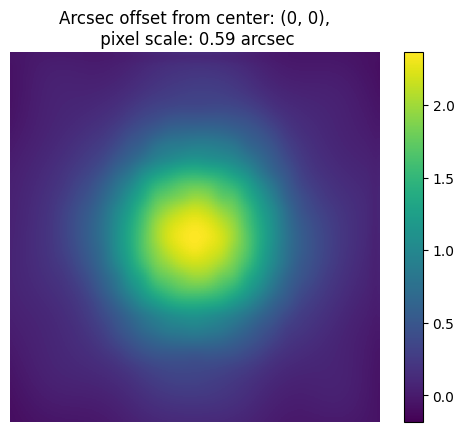

In [6]:
from catalogs import *
thumbnail('../data/uv_test/gaussian.uvfits', (0,0), 5)